In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os

df = pd.read_csv('../outputs/cleaned_data.csv')
os.makedirs('../outputs/charts', exist_ok=True)

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f9f9f9'
plt.rcParams['font.family'] = 'sans-serif'

total = len(df)
left = df['Attrition'].sum()
rate = round((left / total) * 100, 1)
print(f"Total employees : {total}")
print(f"Employees left  : {left}")
print(f"Attrition rate  : {rate}%")

Total employees : 1470
Employees left  : 237
Attrition rate  : 16.1%


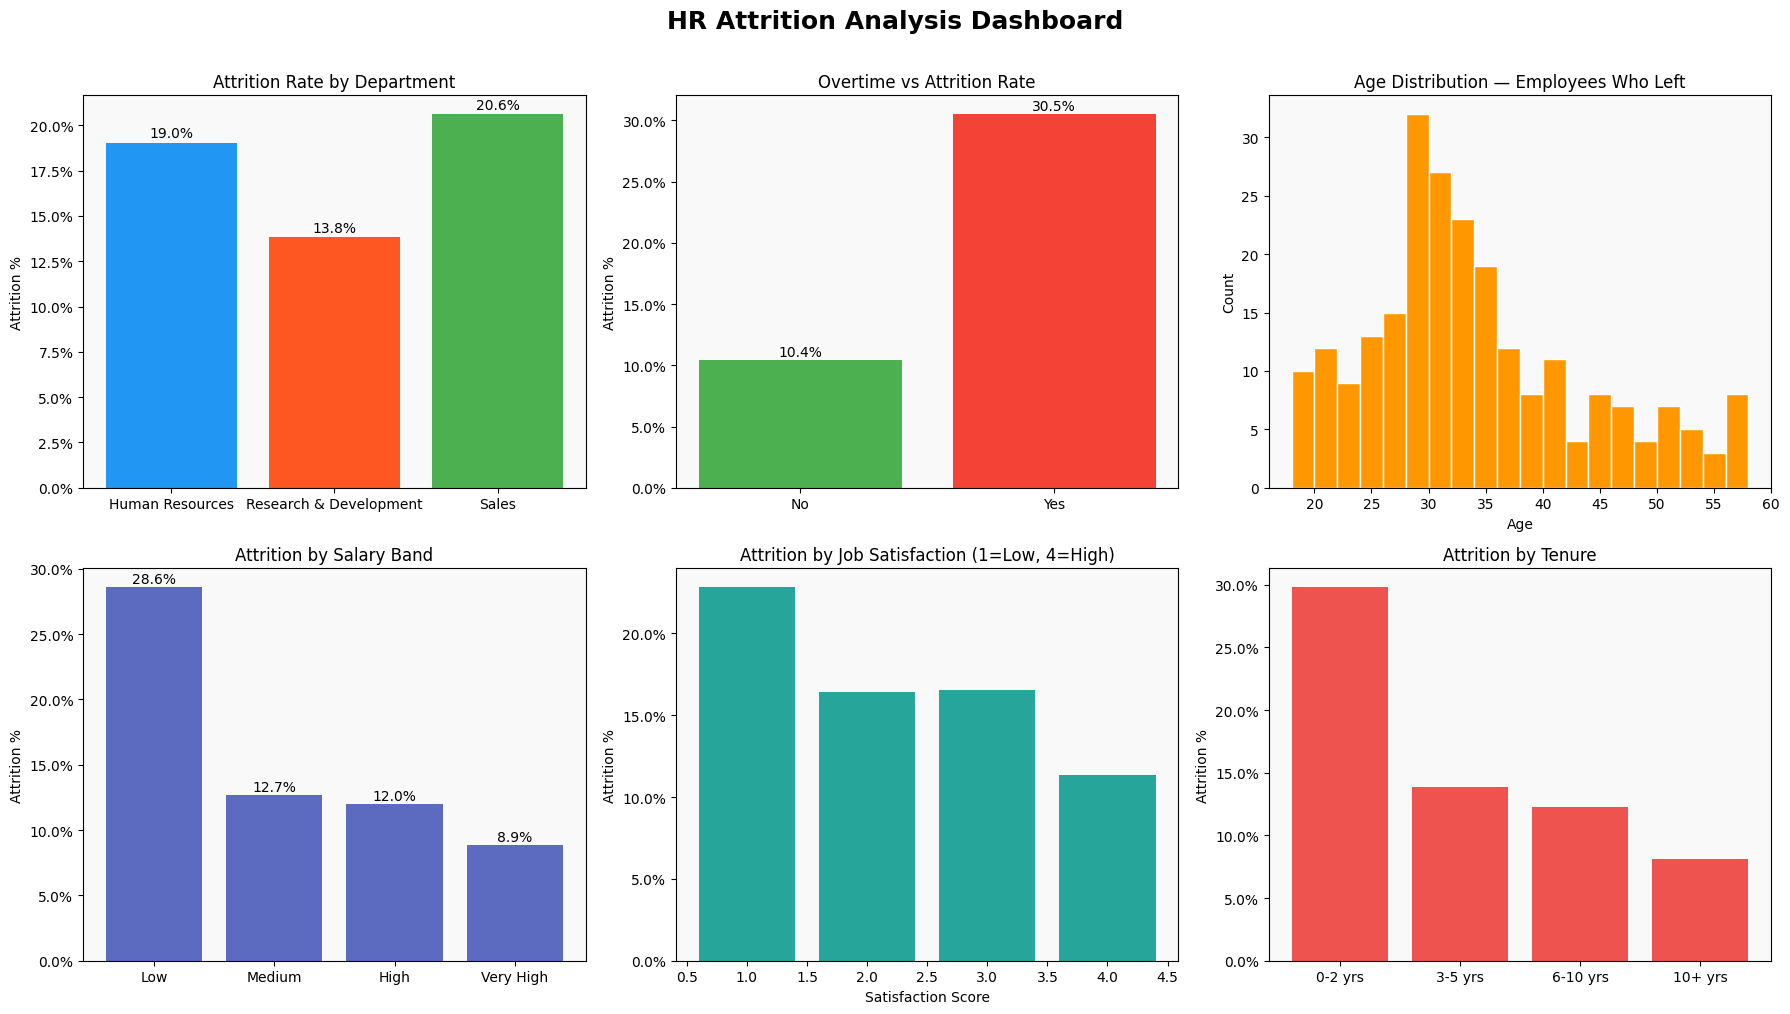

Charts saved.


In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('HR Attrition Analysis Dashboard', fontsize=18, fontweight='bold', y=1.01)

# Chart 1 — by department
dept = df.groupby('Department')['Attrition'].mean() * 100
axes[0,0].bar(dept.index, dept.values, color=['#2196F3','#FF5722','#4CAF50'])
axes[0,0].set_title('Attrition Rate by Department')
axes[0,0].set_ylabel('Attrition %')
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(dept.values):
    axes[0,0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

# Chart 2 — overtime vs no overtime
ot = df.groupby('OverTime')['Attrition'].mean() * 100
colors = ['#4CAF50' if x == 'No' else '#F44336' for x in ot.index]
axes[0,1].bar(ot.index, ot.values, color=colors)
axes[0,1].set_title('Overtime vs Attrition Rate')
axes[0,1].set_ylabel('Attrition %')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(ot.values):
    axes[0,1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

# Chart 3 — age distribution of leavers
axes[0,2].hist(df[df['Attrition']==1]['Age'], bins=20, color='#FF9800', edgecolor='white')
axes[0,2].set_title('Age Distribution — Employees Who Left')
axes[0,2].set_xlabel('Age')
axes[0,2].set_ylabel('Count')

# Chart 4 — salary band
sal_order = ['Low','Medium','High','Very High']
sal = df.groupby('SalaryBand', observed=True)['Attrition'].mean() * 100
sal = sal.reindex(sal_order)
axes[1,0].bar(sal.index, sal.values, color='#5C6BC0')
axes[1,0].set_title('Attrition by Salary Band')
axes[1,0].set_ylabel('Attrition %')
axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(sal.values):
    axes[1,0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

# Chart 5 — job satisfaction
sat = df.groupby('JobSatisfaction')['Attrition'].mean() * 100
axes[1,1].bar(sat.index, sat.values, color='#26A69A')
axes[1,1].set_title('Attrition by Job Satisfaction (1=Low, 4=High)')
axes[1,1].set_xlabel('Satisfaction Score')
axes[1,1].set_ylabel('Attrition %')
axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter())

# Chart 6 — tenure bucket
ten_order = ['0-2 yrs','3-5 yrs','6-10 yrs','10+ yrs']
ten = df.groupby('TenureBucket', observed=True)['Attrition'].mean() * 100
ten = ten.reindex(ten_order)
axes[1,2].bar(ten.index, ten.values, color='#EF5350')
axes[1,2].set_title('Attrition by Tenure')
axes[1,2].set_ylabel('Attrition %')
axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('../outputs/charts/attrition_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved.")

In [3]:
findings = {
    "Overall Attrition Rate"   : f"{rate}%",
    "Employees Who Left"        : int(left),
    "Highest Risk Dept"         : "Sales (20.6%)",
    "Overtime Attrition Rate"   : "30.5% vs 10.4% (No OT)",
    "Low Salary Attrition"      : "28.6%",
    "New Joiner Attrition (0-2 yrs)" : "30.0%",
    "High Risk Employees Flagged"    : int(df['HighRiskFlag'].sum()),
}

print("=" * 45)
print("   KEY FINDINGS — HR ATTRITION ANALYSIS")
print("=" * 45)
for k, v in findings.items():
    print(f"  {k:<35} {v}")
print("=" * 45)

   KEY FINDINGS — HR ATTRITION ANALYSIS
  Overall Attrition Rate              16.1%
  Employees Who Left                  237
  Highest Risk Dept                   Sales (20.6%)
  Overtime Attrition Rate             30.5% vs 10.4% (No OT)
  Low Salary Attrition                28.6%
  New Joiner Attrition (0-2 yrs)      30.0%
  High Risk Employees Flagged         56
